# Conflict-vs-PSE exploratory plots with free psychometric mu, sigma, and lambda

This companion to `plotConflictvsPSE.ipynb` uses the same free per-condition psychometric parameterization for behavior and model simulations.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

from plot_style import (
    setup_style,
    FONT_SIZE_LABEL,
    FONT_SIZE_TITLE,
    FONT_SIZE_LEGEND,
)
from free_psychometric_refits import (
    DEFAULT_MAIN_MODELS,
    DEFAULT_ALL_MODELS,
    collect_free_fits,
    aggregate_free_fits,
    value_label,
)

setup_style()
FONT = FONT_SIZE_LABEL
LINE_WIDTH_DATA = 2.8
LINE_WIDTH_MODEL = 2.4
LINE_WIDTH_AUX = 1.2


In [11]:
PF_MODE = 'lognormal'  # 'lognormal' or 'normal'
FORCE_REFIT = False     # True recomputes and overwrites the free-fit JSON cache

PIDS = ['as', 'dt', 'hh', 'ip', 'ln2', 'mh', 'ml', 'mt', 'oy', 'qs', 'sx']
MAIN_MODELS = DEFAULT_MAIN_MODELS

# Prefer the LapseFree simulations where available; fall back to LapseFix.
MODEL_VARIANTS = ['LapseFree_sharedPrior', 'LapseFix_sharedPrior', 'LapseFree_contextualPrior']

DATA_COLOR = {0.1: '#d62728', 1.2: '#1f77b4'}
MODEL_STYLE = {
    'lognorm':           dict(label='Causal inference', color='#600c70', ls='-',  marker='o'),
    'fusionOnlyLogNorm': dict(label='Forced fusion',    color='#2ca02c', ls='--', marker='s'),
    'switchingFree':     dict(label='Cue switching',    color='#080529', ls=':',  marker='^'),
}


In [12]:
data_pp, model_pp, missing = collect_free_fits(
    PIDS,
    model_names=MAIN_MODELS,
    pf_mode=PF_MODE,
    force=FORCE_REFIT,
    variants=MODEL_VARIANTS,
)

print(f'Data rows:  {len(data_pp)}')
print(f'Model rows: {len(model_pp)}')
if missing:
    print('Missing simulated CSVs:')
    for pid, model in missing:
        print(f'  {pid}/{model}')

print('\nData sample:')
display(data_pp.head())
print('\nModel sample:')
display(model_pp.head())


Data rows:  154
Model rows: 462

Data sample:


,pid,audioNoise,conflict,conflict_ms,n_trials,mu,sigma,lambda_,nll,success,mu_shift_s,mu_shift_ms,sigma_plot
0,as,0.1,-0.25,-250,155,-0.071989,0.350865,0.0,69.320984,True,-0.034729,-34.729222,0.350865
1,as,0.1,-0.17,-170,164,-0.042469,0.358352,0.0,77.655886,True,-0.020790,-20.789825,0.358352
2,as,0.1,-0.08,-80,142,0.023642,0.275329,0.0,55.970283,True,0.011962,11.961819,0.275329
3,as,0.1,0.00,0,146,-0.040905,0.346234,0.0,64.932543,True,-0.020040,-20.039912,0.346234
4,as,0.1,0.08,80,153,0.021254,0.303179,0.0,59.628045,True,0.010741,10.740912,0.303179



Model sample:


,pid,model,audioNoise,conflict,conflict_ms,n_trials,mu,sigma,lambda_,nll,success,mu_shift_s,mu_shift_ms,sigma_plot
0,as,lognorm,0.1,-0.25,-250,4650,-0.076120,0.297917,0.037353,1984.051760,True,-0.036648,-36.647700,0.297917
1,as,lognorm,0.1,-0.17,-170,4920,-0.050702,0.296650,0.052827,2232.093371,True,-0.024719,-24.719033,0.296650
2,as,lognorm,0.1,-0.08,-80,4260,-0.017537,0.293038,0.081517,1985.477509,True,-0.008692,-8.691921,0.293038
3,as,lognorm,0.1,0.00,0,4380,-0.004671,0.306188,0.029689,1910.528137,True,-0.002330,-2.330065,0.306188
4,as,lognorm,0.1,0.08,80,4590,0.033386,0.268285,0.033229,1776.738938,True,0.016975,16.974541,0.268285


In [13]:
def make_aggregates(value_col='mu_shift_s'):
    data_agg = aggregate_free_fits(data_pp, value_col=value_col)
    model_agg = aggregate_free_fits(model_pp, value_col=value_col)
    return data_agg, model_agg


def _scale_for_value(value_col):
    return 1000.0 if value_col == 'mu_shift_s' else 1.0


def plot_grouped_free(value_col='mu_shift_s', save_prefix=None):
    data_agg, model_agg = make_aggregates(value_col)
    scale = _scale_for_value(value_col)
    y_label = value_label(value_col, pf_mode=PF_MODE)

    audio_levels = sorted(data_agg['audioNoise'].unique())
    fig, axes = plt.subplots(1, len(audio_levels), figsize=(14, 6.5), sharey=False)
    if len(audio_levels) == 1:
        axes = [axes]

    handles = []
    labels = []
    panel_titles = ['A', 'B']

    for idx, (ax, noise) in enumerate(zip(axes, audio_levels)):
        d = data_agg[data_agg['audioNoise'] == noise].sort_values('conflict')
        x = d['conflict'].to_numpy(float) * 1000
        y = d['mean'].to_numpy(float) * scale
        yerr = d['sem'].to_numpy(float) * scale
        ax.errorbar(
            x, y, yerr=yerr, fmt='o-', color=DATA_COLOR.get(noise, 'black'),
            capsize=5, linewidth=LINE_WIDTH_DATA, markersize=8, zorder=5,
            markeredgecolor='white', markeredgewidth=1.0,
        )
        if idx == 0:
            handles.append(Line2D([0], [0], color=DATA_COLOR.get(noise, 'black'), marker='o', lw=LINE_WIDTH_DATA))
            labels.append('Data')

        for model_name in MAIN_MODELS:
            m = model_agg[(model_agg['audioNoise'] == noise) & (model_agg['model'] == model_name)].sort_values('conflict')
            if m.empty:
                continue
            style = MODEL_STYLE.get(model_name, dict(label=model_name, color='gray', ls='-', marker='o'))
            xm = m['conflict'].to_numpy(float) * 1000
            ym = m['mean'].to_numpy(float) * scale
            merr = m['sem'].to_numpy(float) * scale
            ax.errorbar(
                xm, ym, yerr=merr, color=style['color'], linestyle=style['ls'],
                marker=style['marker'], capsize=3, linewidth=LINE_WIDTH_MODEL, markersize=6,
                markerfacecolor=style['color'], markeredgecolor='white', markeredgewidth=0.8,
            )
            if idx == 0:
                handles.append(Line2D([0], [0], color=style['color'], ls=style['ls'], marker=style['marker'], lw=LINE_WIDTH_MODEL))
                labels.append(style['label'])

        ax.axhline(0, color='gray', linestyle='--', linewidth=LINE_WIDTH_AUX, alpha=0.65)
        ax.axvline(0, color='gray', linestyle='--', linewidth=LINE_WIDTH_AUX, alpha=0.65)
        ax.margins(y=0.18)
        ax.set_title(panel_titles[idx], loc='left', pad=10)
        ax.set_xlabel('Cue conflict (ms)')
        ax.tick_params(axis='x', rotation=0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[0].set_ylabel(y_label)
    handles.append(Line2D([], [], color='none'))
    labels.append(f'mean +/- SEM (n={len(PIDS)})')
    fig.legend(handles, labels, loc='lower center',
               bbox_to_anchor=(0.5, -0.03), ncol=5, frameon=True, edgecolor='black')
    plt.tight_layout(rect=(0, 0.08, 1, 1))

    if save_prefix:
        fig.savefig(f'{save_prefix}.png', dpi=300, bbox_inches='tight')
        fig.savefig(f'{save_prefix}.pdf', dpi=900, bbox_inches='tight')
        fig.savefig(f'{save_prefix}.svg', bbox_inches='tight')
        print(f'Saved {save_prefix}.png/.pdf/.svg')
    plt.show()
    return data_agg, model_agg


Saved aggregated_mu_vs_models_freeMuSigmaLambda_sem.png/.pdf/.svg


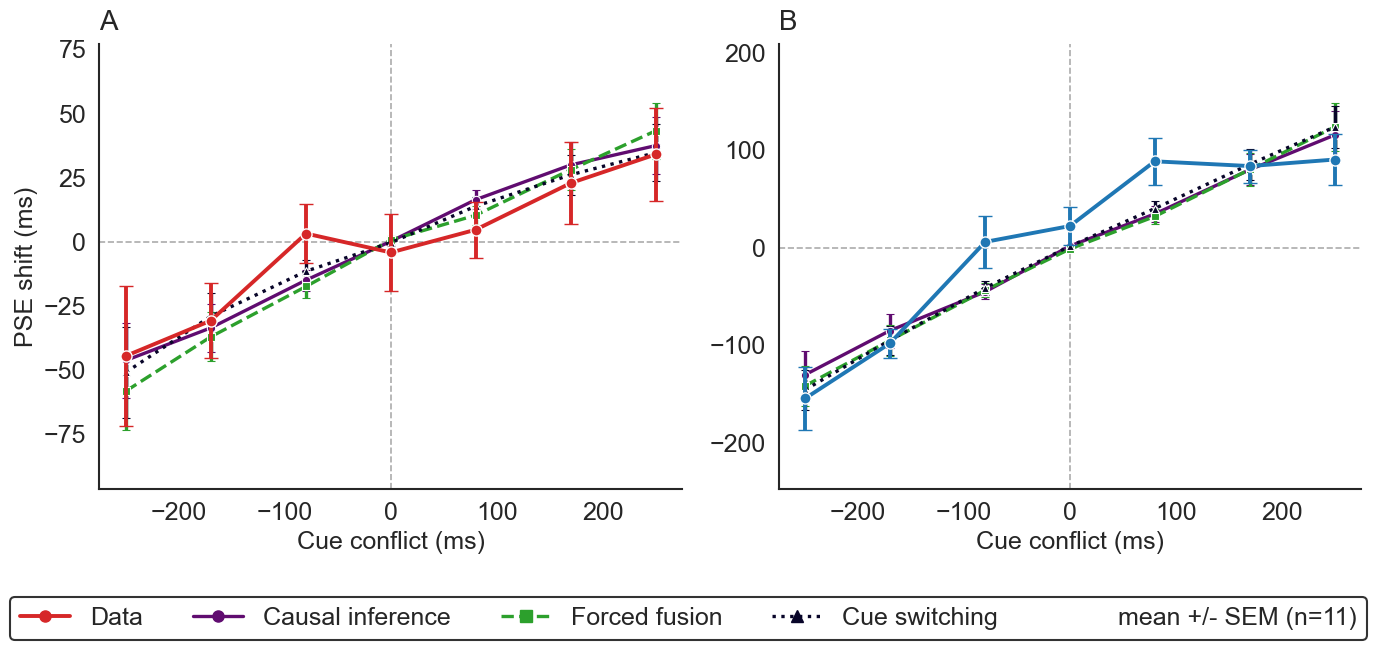

In [14]:
mu_data_agg, mu_model_agg = plot_grouped_free(
    'mu_shift_s',
    save_prefix='aggregated_mu_vs_models_freeMuSigmaLambda_sem',
)


Saved aggregated_sigma_vs_models_freeMuSigmaLambda_sem.png/.pdf/.svg


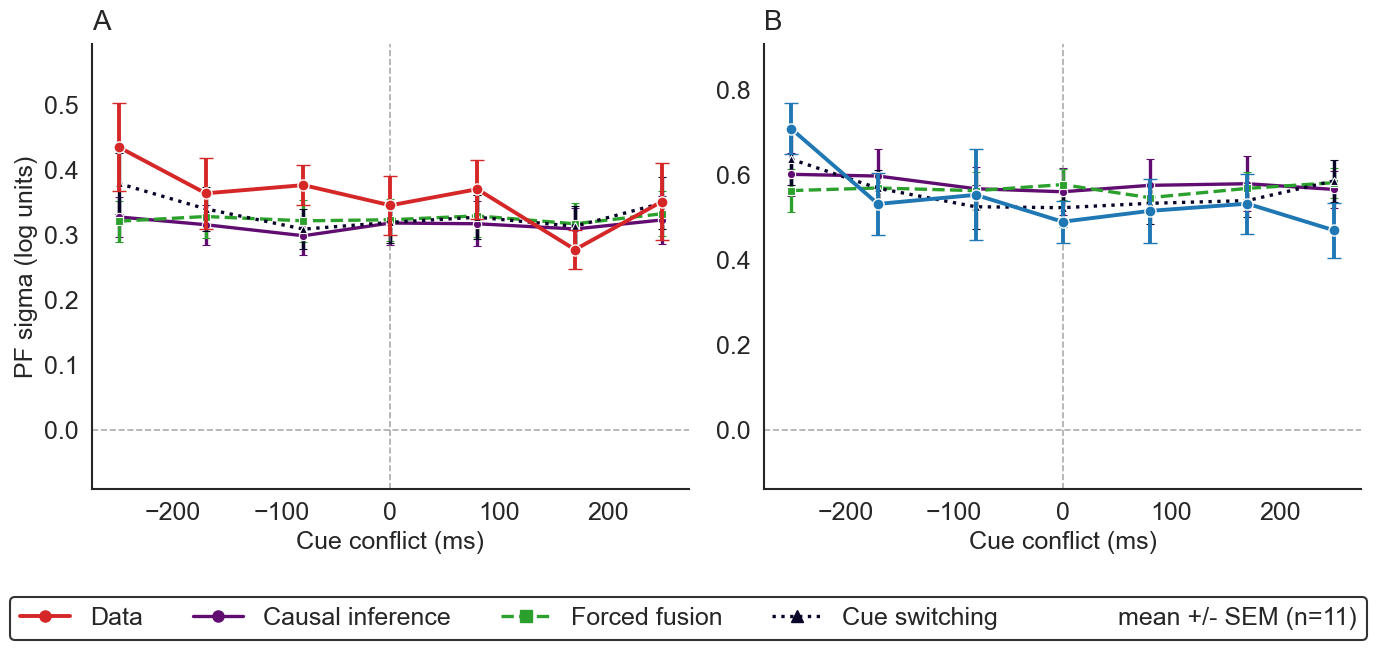

Saved aggregated_lambda_vs_models_freeMuSigmaLambda_sem.png/.pdf/.svg


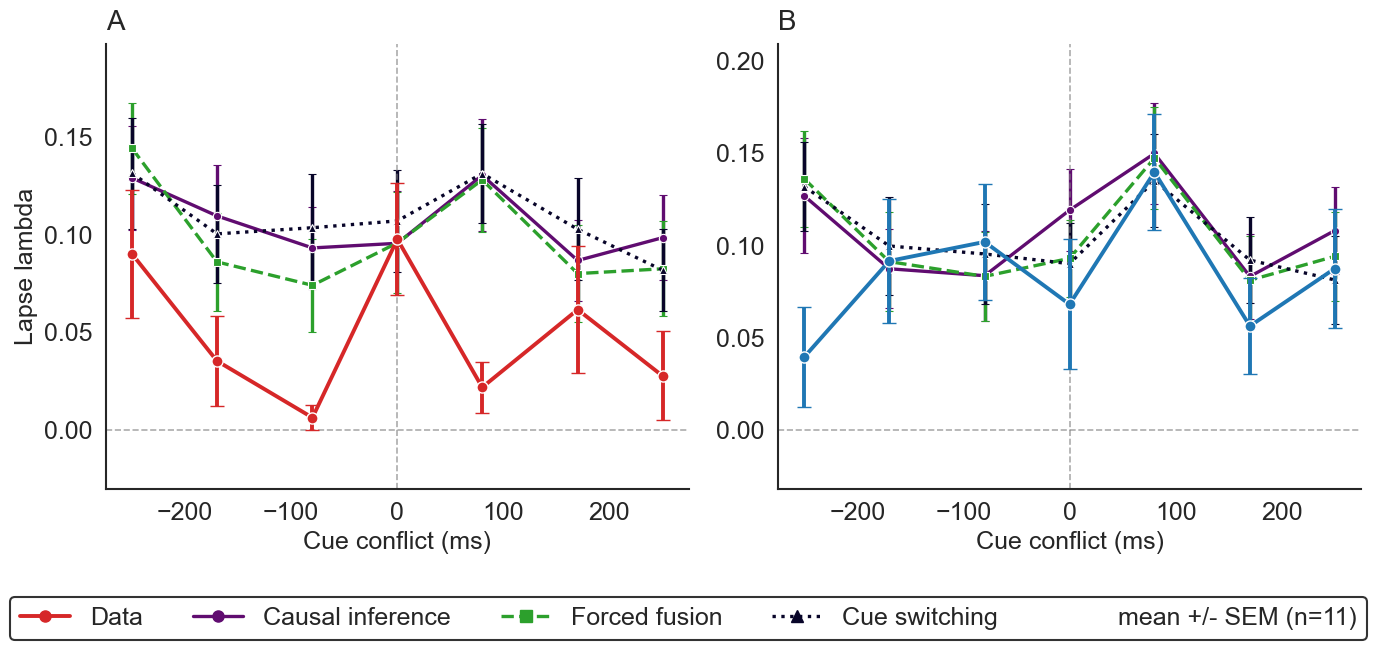

In [15]:
sigma_data_agg, sigma_model_agg = plot_grouped_free(
    'sigma_plot',
    save_prefix='aggregated_sigma_vs_models_freeMuSigmaLambda_sem',
)

lambda_data_agg, lambda_model_agg = plot_grouped_free(
    'lambda_',
    save_prefix='aggregated_lambda_vs_models_freeMuSigmaLambda_sem',
)


Saved per_participant_mu_freeMuSigmaLambda.png/.pdf


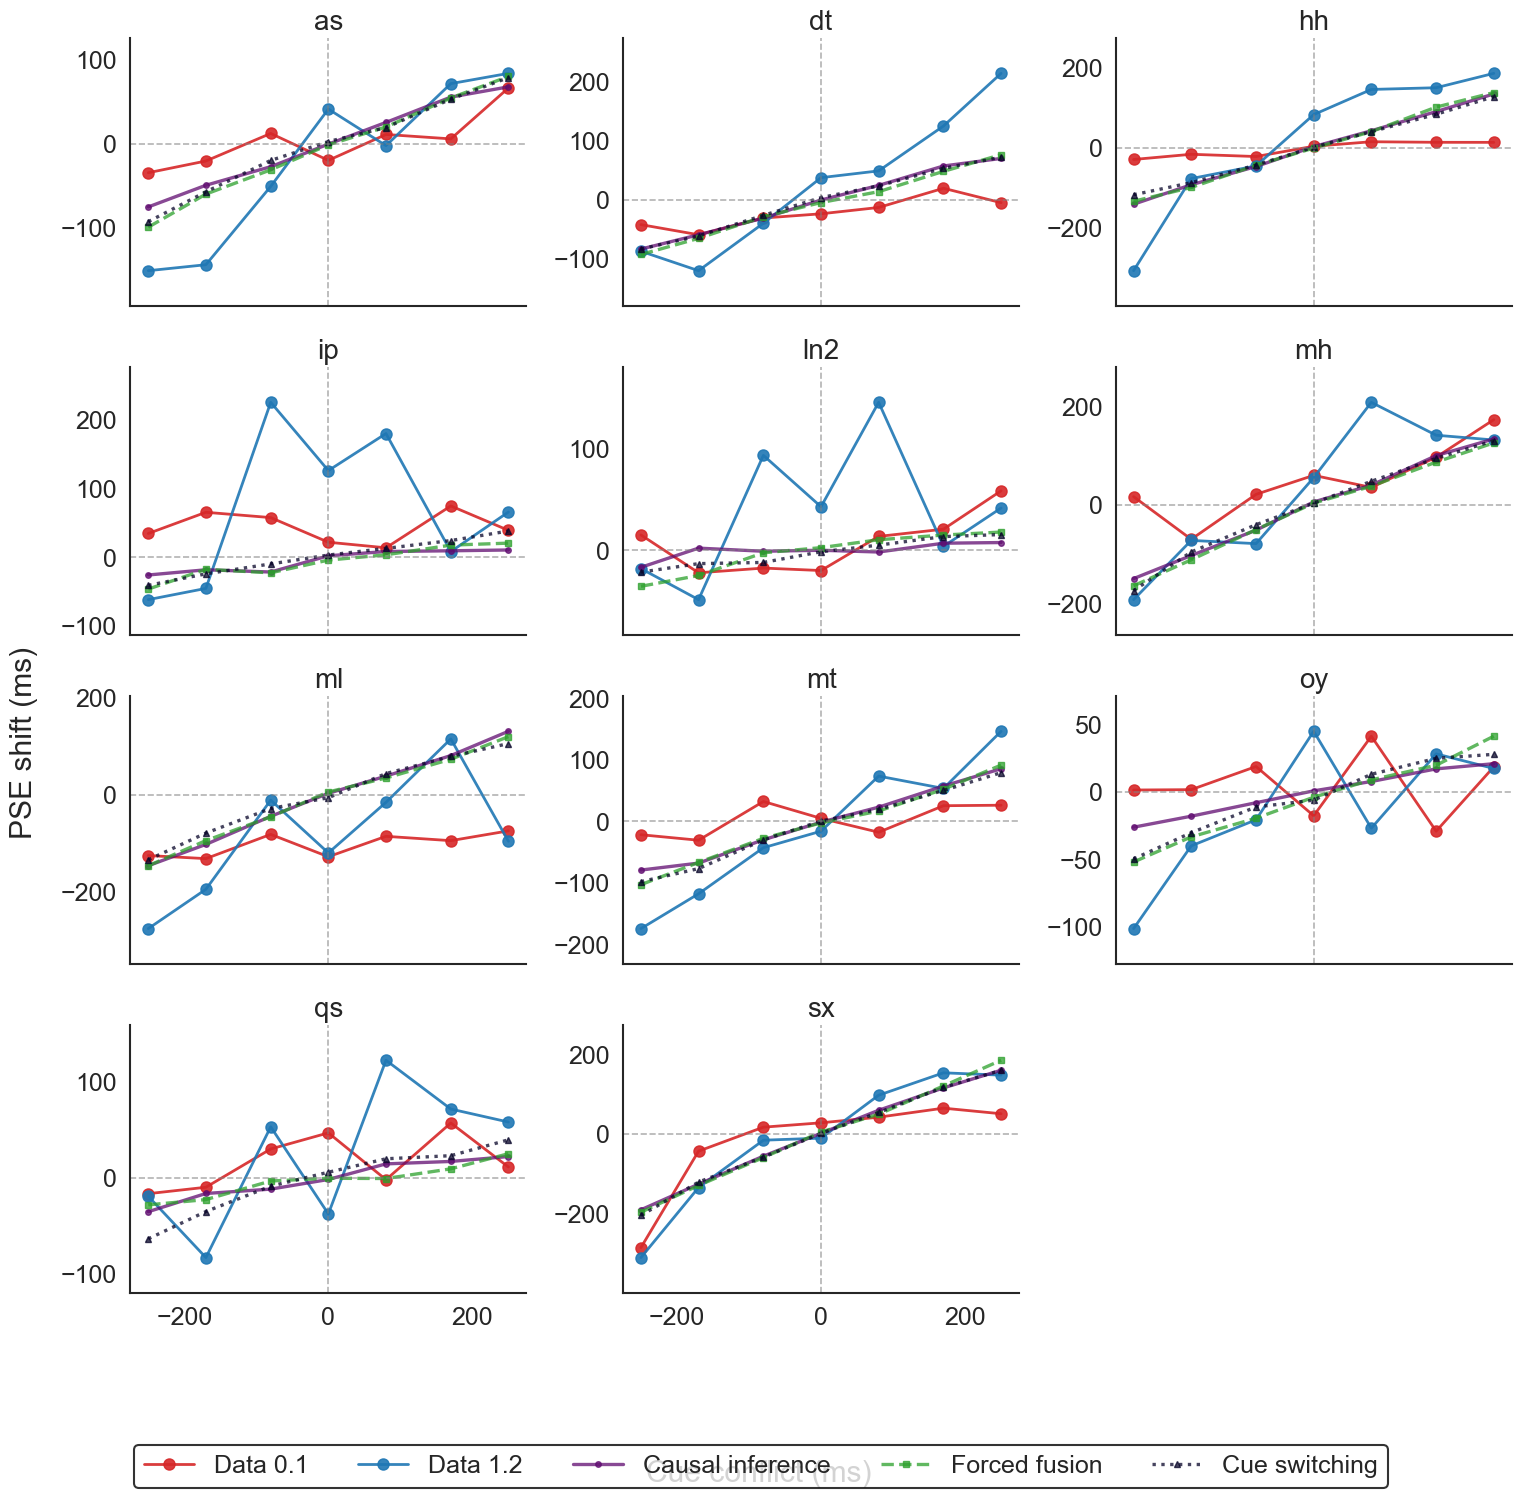

In [16]:
def plot_per_participant_free(value_col='mu_shift_s', models=MAIN_MODELS, save_prefix=None):
    scale = _scale_for_value(value_col)
    y_label = value_label(value_col, pf_mode=PF_MODE)
    n_cols = 3
    n_rows = int(np.ceil(len(PIDS) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.8 * n_rows), sharex=True, sharey=False)
    axes = np.asarray(axes).reshape(-1)

    for ax, pid in zip(axes, PIDS):
        dp = data_pp[data_pp['pid'] == pid]
        for noise in sorted(dp['audioNoise'].unique()):
            d = dp[dp['audioNoise'] == noise].sort_values('conflict')
            ax.plot(d['conflict'] * 1000, d[value_col] * scale, 'o-',
                    color=DATA_COLOR.get(noise, 'black'), alpha=0.9,
                    label=f'Data {noise}' if pid == PIDS[0] else None)

        for model_name in models:
            mp = model_pp[(model_pp['pid'] == pid) & (model_pp['model'] == model_name)]
            if mp.empty:
                continue
            style = MODEL_STYLE.get(model_name, dict(label=model_name, color='gray', ls='-', marker='o'))
            collapsed = mp.groupby('conflict')[value_col].mean().reset_index().sort_values('conflict')
            ax.plot(collapsed['conflict'] * 1000, collapsed[value_col] * scale,
                    linestyle=style['ls'], marker=style['marker'], color=style['color'],
                    alpha=0.75, linewidth=LINE_WIDTH_MODEL, markersize=4,
                    label=style['label'] if pid == PIDS[0] else None)

        ax.axhline(0, color='gray', linestyle='--', linewidth=LINE_WIDTH_AUX, alpha=0.6)
        ax.axvline(0, color='gray', linestyle='--', linewidth=LINE_WIDTH_AUX, alpha=0.6)
        ax.margins(y=0.18)
        ax.set_title(pid)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    for ax in axes[len(PIDS):]:
        ax.axis('off')

    fig.supxlabel('Cue conflict (ms)')
    fig.supylabel(y_label)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5, frameon=True, edgecolor='black')
    plt.tight_layout(rect=(0, 0.06, 1, 1))
    if save_prefix:
        fig.savefig(f'{save_prefix}.png', dpi=300, bbox_inches='tight')
        fig.savefig(f'{save_prefix}.pdf', dpi=900, bbox_inches='tight')
        print(f'Saved {save_prefix}.png/.pdf')
    plt.show()

plot_per_participant_free('mu_shift_s', save_prefix='per_participant_mu_freeMuSigmaLambda')


## Optional: all simulated model families

This section fits every model family available in `simulated_data/`. It is slower than the three-model section but uses the same cache, so repeated runs are cheap unless `FORCE_REFIT=True`.

In [17]:
ALL_MODELS = DEFAULT_ALL_MODELS
all_data_pp, all_model_pp, all_missing = collect_free_fits(
    PIDS,
    model_names=ALL_MODELS,
    pf_mode=PF_MODE,
    force=FORCE_REFIT,
    variants=MODEL_VARIANTS,
)

print(f'All-model rows: {len(all_model_pp)}')
if all_missing:
    print('Missing all-model simulations:')
    for pid, model in all_missing[:30]:
        print(f'  {pid}/{model}')
    if len(all_missing) > 30:
        print(f'  ... {len(all_missing) - 30} more')


All-model rows: 1694


Saved all_models_mu_freeMuSigmaLambda_grid.png/.pdf/.svg


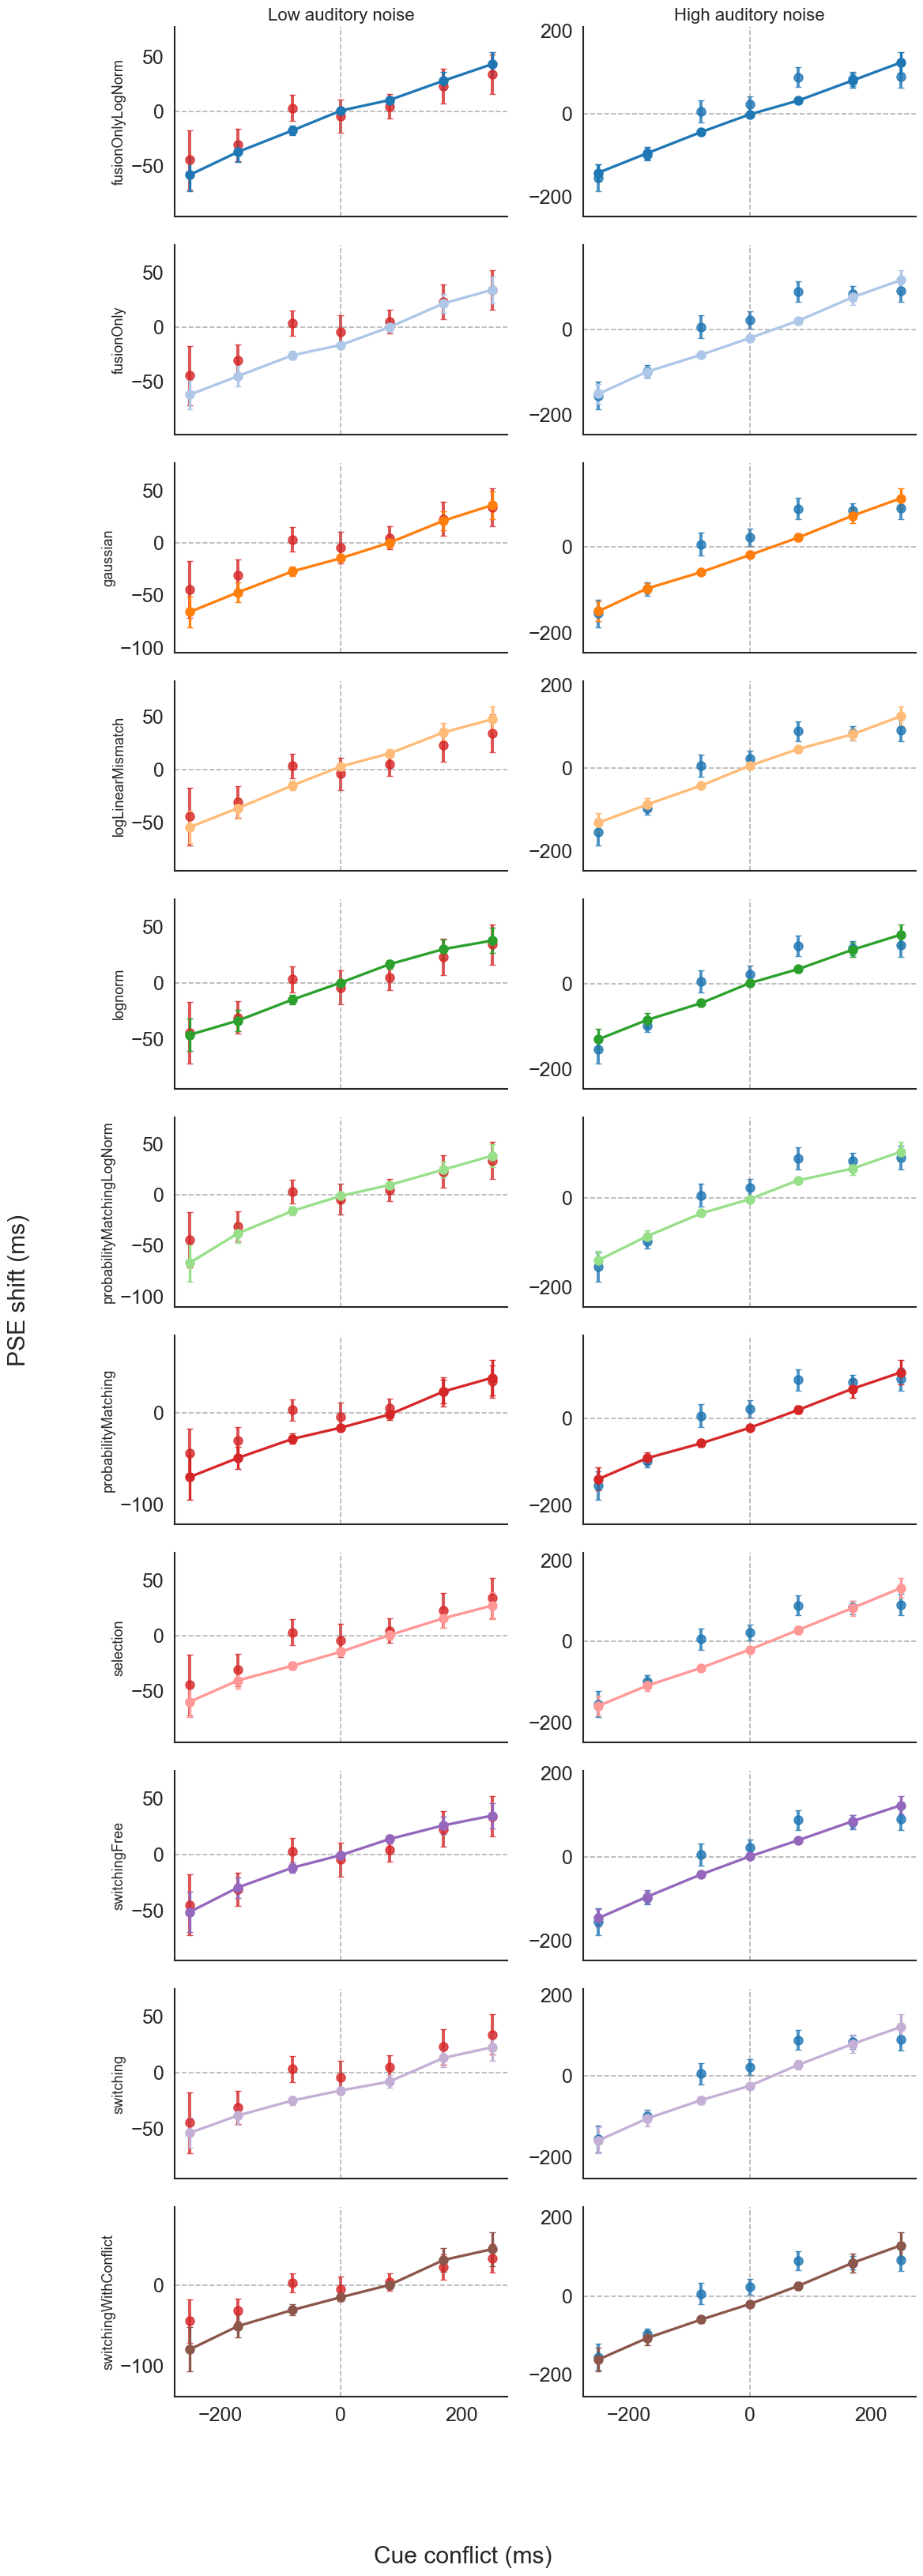

In [18]:
def plot_all_models_grid(value_col='mu_shift_s', save_prefix='all_models_freeMuSigmaLambda_grid'):
    data_agg = aggregate_free_fits(all_data_pp, value_col=value_col)
    model_agg = aggregate_free_fits(all_model_pp, value_col=value_col)
    scale = _scale_for_value(value_col)
    audio_levels = sorted(data_agg['audioNoise'].unique())
    models = [m for m in ALL_MODELS if m in set(model_agg['model'])]

    fig, axes = plt.subplots(len(models), len(audio_levels), figsize=(12, max(3.0 * len(models), 5)),
                             sharex=True, sharey=False, squeeze=False)
    palette = dict(zip(models, sns.color_palette('tab20', n_colors=len(models))))

    for ri, model_name in enumerate(models):
        for ci, noise in enumerate(audio_levels):
            ax = axes[ri, ci]
            d = data_agg[data_agg['audioNoise'] == noise].sort_values('conflict')
            ax.errorbar(d['conflict'] * 1000, d['mean'] * scale, yerr=d['sem'] * scale,
                        color=DATA_COLOR.get(noise, 'black'), fmt='o', capsize=3,
                        linewidth=LINE_WIDTH_DATA, alpha=0.8)
            m = model_agg[(model_agg['audioNoise'] == noise) & (model_agg['model'] == model_name)].sort_values('conflict')
            if not m.empty:
                ax.errorbar(m['conflict'] * 1000, m['mean'] * scale, yerr=m['sem'] * scale,
                            color=palette[model_name], fmt='o-', capsize=3,
                            linewidth=LINE_WIDTH_MODEL)
            ax.axhline(0, color='gray', linestyle='--', linewidth=LINE_WIDTH_AUX, alpha=0.6)
            ax.axvline(0, color='gray', linestyle='--', linewidth=LINE_WIDTH_AUX, alpha=0.6)
            ax.margins(y=0.18)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            if ri == 0:
                ax.set_title('Low auditory noise' if ci == 0 else 'High auditory noise', fontsize=FONT - 2)
            if ci == 0:
                ax.set_ylabel(model_name, fontsize=FONT - 5)

    fig.supxlabel('Cue conflict (ms)')
    fig.supylabel(value_label(value_col, pf_mode=PF_MODE))
    plt.tight_layout(rect=(0.05, 0.04, 1, 1))
    if save_prefix:
        fig.savefig(f'{save_prefix}.png', dpi=300, bbox_inches='tight')
        fig.savefig(f'{save_prefix}.pdf', dpi=900, bbox_inches='tight')
        fig.savefig(f'{save_prefix}.svg', bbox_inches='tight')
        print(f'Saved {save_prefix}.png/.pdf/.svg')
    plt.show()

plot_all_models_grid('mu_shift_s', save_prefix='all_models_mu_freeMuSigmaLambda_grid')
